# **Assignment Two**
**Student Name:** Jessica Mawuenam Dellason

**Student Number:** 25215734

This project will be based on [Review Files]("http://mlg.ucd.ie/modules/python/reviews.zip")

## **AI Declaration Statement**

Generative AI tools (ChatGPT, OpenAI GPT-5.3) were used to support this assignment. AI assistance was used for:

* Clarifying the meaning of specific data patterns (e.g., `#oc-` prefixes in `user_id`, interpreted as anonymous or special users)
* Converting HTML content into plain text using appropriate libraries
* Cleaning and preprocessing text data, including removing special characters and standardising text

All code was reviewed, adapted, and implemented by me. The analysis, results, and interpretations presented are my own work.


In [173]:
# Import necessary libraries
import json
import pandas as pd
from bs4 import BeautifulSoup
import re
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.feature_extraction.text import TfidfVectorizer

---
## **Task 1: Data Preparation and Characterisation**

### Data Loading and Merging

The dataset was provided in two separate JSON files: one containing review text and the other containing ratings and helpfulness information. These were loaded into separate DataFrames and then merged using the `review_id` column.

The `review_id` was used as the merge key because it is a unique identifier present in both datasets, ensuring that each review’s text is correctly matched with its corresponding score data.

The merged dataset was then saved as a CSV file for easier access in later stages of the analysis.


In [174]:
# Load 'review-scores.json' and 'reviews/review-text.json' file into a DataFrame
try:
    with open("reviews/review-scores.json", 'r') as scores_file, open("reviews/review-text.json", 'r') as text_file:
        scores_df = pd.DataFrame(json.loads(scores_file.read()))
        text_df = pd.DataFrame(json.loads(text_file.read()))

except FileNotFoundError:
    print("Either 'reviews/review-scores.json' or 'reviews/review-text.json' file not found")

# Merge 'scores_df' and 'text_df' on review_id
reviews_df = text_df.merge(scores_df, on = "review_id")

# Save merged data into csv file
reviews_df.to_csv("reviews.csv", index= False)

### Missing Values Check

A check for missing values was performed using `isna().sum()` to identify any incomplete data within the dataset. This step is important to ensure data quality before further analysis, as missing values can negatively affect model performance and results.

The output shows the number of missing entries in each column, allowing for informed decisions on whether to clean, remove, or handle incomplete data.

In [175]:
# Check for missing cells
reviews_df.isna().sum()

review_id         0
product_id        0
user_id           0
review_title     45
review_body      45
review_date       0
rating            0
helpful_votes     0
total_votes       0
dtype: int64

### Inspecting Review ID

The `review_id` column was examined to ensure data integrity. All values were confirmed to start with the prefix **"R"**, indicating a consistent format across the dataset. Additionally, each `review_id` was verified to be unique, confirming that there are no duplicate reviews.

Given these properties, `review_id` was set as the index of the DataFrame. This provides a reliable and meaningful way to reference each individual review throughout the analysis.

In [176]:
# Verify that every review_id includes "R" (returns True if all do)
print(f"All 'review_id' start with 'R': {reviews_df[reviews_df["review_id"].str.startswith("R")].shape[0] == reviews_df.shape[0]}")

# Verify that each review_id is unique
print(f"Each 'review_id' is unique: {reviews_df["review_id"].nunique() == reviews_df.shape[0]}")

# Set 'review_id' as index
reviews_df.set_index('review_id', inplace=True)

All 'review_id' start with 'R': True
Each 'review_id' is unique: True


### Inspecting Product ID
The `product_id` column was checked for consistency. It was found that most values contain the prefix **"B"**, which appears to be the standard format. However, 6 entries were identified as purely numeric, likely due to a data extraction or formatting issue.

To ensure consistency across the dataset, the prefix **"B"** was added to these entries. After this correction, all `product_id` values follow the same format, improving data quality and reliability for further analysis.

In [177]:
# Verify that every product_id includes "B" (returns True if all do)
print(f"All 'product_id' conatain 'B': {reviews_df[reviews_df["product_id"].str.contains("B")].shape[0] == reviews_df.shape[0]}")

# Get the reviews whose product_id does not contain 'B'
print(f"All 'product_id' not conataining 'B': {reviews_df[~reviews_df["product_id"].str.contains("B")].shape[0]}")

# Iterate over rows where product_id does NOT contain "B" and attach B to the beginning
for index, row in reviews_df[~reviews_df["product_id"].str.contains("B")].iterrows():
    reviews_df.loc[index, "product_id"] = 'B' + str(row["product_id"])

# Verify all rows
print(f"All 'product_id' conatain 'B': {reviews_df[reviews_df["product_id"].str.contains("B")].shape[0] == reviews_df.shape[0]}")

All 'product_id' conatain 'B': False
All 'product_id' not conataining 'B': 6
All 'product_id' conatain 'B': True


### Inspecting User ID

The `user_id` column was examined to ensure consistency in formatting. Most values begin with the prefix **"A"**, indicating standard user identifiers. However, 24 entries were found to start with `#oc-R`, likely representing anonymous or special users.

It seems that:  
- `A` → regular users  
- `R` → special users (from `#oc-R`)  
  
To standardise the format, the `#oc-` prefix was removed while retaining the rest of the identifier. This ensures consistency across all `user_id` values without losing any meaningful information.

In [178]:
# Verify that every user_id starts with "A" (returns True if all do)
print(f"All 'user_id' starts with 'A': {reviews_df[reviews_df["user_id"].str.startswith("A")].shape[0] == reviews_df.shape[0]}")

# Get the reviews whose user_id does not start with 'A'
print(f"All 'user_id' not starting with 'A': {reviews_df[~reviews_df["user_id"].str.startswith("A")].shape[0]}")

# View the dataframe
print(f"Dataframe of user_id not starting with A:\n{reviews_df[~reviews_df["user_id"].str.startswith("A")].iloc[:,0:2]}")
 
# Remove "#oc-" prefix from all user_id values
reviews_df["user_id"] = reviews_df["user_id"].str.replace("#oc-", "", regex=False)

All 'user_id' starts with 'A': False
All 'user_id' not starting with 'A': 24
Dataframe of user_id not starting with A:
           product_id             user_id
review_id                                
R136454    B006Q820X0  #oc-R14ZUK54VMOGJS
R136363    B006Q820X0   #oc-RV1CL5MB39LEK
R136470    B006Q820X0  #oc-R3376HJIKZWS95
R516118    B008I1XPKA  #oc-R1AQH0RQMTL1Y9
R516116    B008I1XPKA   #oc-R3HMF6ODAC2R4
R212349    B005EF0I0I  #oc-R2ZTU0FEJBQXE7
R136446    B006Q820X0  #oc-R11T1PHWNO7KEZ
R136455    B006Q820X0  #oc-R152UR09M996EM
R136429    B006Q820X0  #oc-R2GDRKIV15IZHW
R136430    B006Q820X0  #oc-R2O4E9SPR08RNA
R83654     B005ZBZLT4  #oc-R2I896V302UXAQ
R181219    B007Y59HVM   #oc-RPS46SRDKTRZI
R124841    B005EF0HRM  #oc-R3NZKZGLJEKBN3
R181208    B007Y59HVM  #oc-R2I896V302UXAQ
R136487    B006Q820X0  #oc-R1GUQD6SLYACOQ
R124838    B005EF0HRM  #oc-R2ULR70UT6GZPQ
R136416    B006Q820X0  #oc-R2CIG5JYXHVPEE
R83668     B005ZBZLT4  #oc-R2C7F72WD2NEUW
R541159    B005EF0HTK  #oc-R1ZR5L29T4LSAE

### Inspecting Rating

The `rating` column was originally represented using star symbols (`*`). To make the data suitable for analysis, these were converted into numeric values by counting the number of stars (e.g., `****` becomes 4).

This transformation allows the ratings to be used in calculations, visualisations, and as a target variable for machine learning models.


In [179]:
# Convert star ratings (e.g. "***") to numeric values (3)
reviews_df["rating"] = reviews_df["rating"].str.len()

### Inspecting Review Date

The `review_date` column was converted to a datetime format to enable time-based analysis. Since the dataset contained multiple date formats, the parameter `format='mixed'` was used to correctly parse all entries.

This ensures that the column can be used for sorting, filtering, and analysing trends over time.

In [180]:
# Change 'review_date' to date format
reviews_df["review_date"] = pd.to_datetime(reviews_df["review_date"], format='mixed')

### Inspecting Review Body

The `review_body` column contained HTML tags (e.g., `<br>`, `<p>`), which are not useful for text analysis. These were removed by converting the HTML content into plain text using `BeautifulSoup`.

Additionally, non-string values were handled by replacing them with an empty string to prevent errors during processing. This ensures that the text data is clean and suitable for further analysis and modelling.

In [181]:
def html_to_text(html):
    if not isinstance(html, str):
        return ""
    return BeautifulSoup(html, "html.parser").get_text(separator=" ")

# Overwrite the existing column
reviews_df["review_body"] = reviews_df["review_body"].apply(html_to_text)

### Inspecting Review Title

The `review_title` column was cleaned and standardised to improve consistency and readability. First, leading and trailing whitespace was removed to eliminate unnecessary spacing. The text was then converted to title case to ensure a uniform format across all entries. Finally, special characters were removed, retaining only alphanumeric characters and spaces.

Non-string values were left unchanged to avoid processing errors. This cleaning step ensures that the review titles are in a consistent format for analysis and presentation.

In [182]:
# Remove whitespace
reviews_df["review_title"] = reviews_df["review_title"].str.strip()

# Format text 
reviews_df["review_title"] = reviews_df["review_title"].str.title()

# Remove special characters
reviews_df["review_title"] = reviews_df["review_title"].apply(
    lambda x: re.sub(r"[^a-zA-Z0-9\s]", "", x) if isinstance(x, str) else x
)

### Dataset Overview

An initial exploration of the dataset was conducted to understand its structure and key characteristics. The dataset contains **15,375 reviews** across **8 columns**, with `review_id` used as a unique index.

There are a small number of missing values in both the `review_title` and `review_body` columns (45 each), which is relatively minor compared to the overall dataset size.

The reviews span a date range from **2021-01-01 to 2025-12-30**, allowing for potential time-based analysis. In terms of diversity, there are **6,331 unique products** and **9,786 unique users**, indicating a broad and varied dataset. The most frequently reviewed product appears 90 times, while the most active user has 104 reviews.

Overall, the dataset is sufficiently large, diverse, and well-structured for performing sentiment and helpfulness classification tasks.

#### Quick Summary
- **Total reviews:** 15,375  
- **Columns:** 8 (product_id, user_id, review_title, review_body, review_date, rating, helpful_votes, total_votes)  
- **Index:** review_id (unique)  
- **Missing values:** review_title (45 missing) , review_body (45 missing) 
- **Review dates:** From 2021-01-01 to 2025-12-30  
- **product_id:** 6,331 unique, most frequent appears 90 times  
- **user_id:** 9,786 unique, most frequent appears 104 times  

In [183]:
# Overview of dataset
print(reviews_df.info()) 

# Summary statistics for numerical features
print(reviews_df.describe())

# Summary for categorical/text features
print(reviews_df[["product_id", "user_id"]].describe(include="object"))

# Look at first few rows
reviews_df.head()

<class 'pandas.DataFrame'>
Index: 15375 entries, R274002 to R327437
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   product_id     15375 non-null  str           
 1   user_id        15375 non-null  str           
 2   review_title   15330 non-null  str           
 3   review_body    15375 non-null  str           
 4   review_date    15375 non-null  datetime64[us]
 5   rating         15375 non-null  int64         
 6   helpful_votes  15375 non-null  int64         
 7   total_votes    15375 non-null  int64         
dtypes: datetime64[us](1), int64(3), str(4)
memory usage: 1.6+ MB
None
                      review_date        rating  helpful_votes   total_votes
count                       15375  15375.000000   15375.000000  15375.000000
mean   2023-06-28 04:38:54.907317      3.414504      21.933268     27.129041
min           2021-01-01 00:00:00      1.000000       0.000000     12.000000
25%        

/var/folders/07/s8x8wk454bn62q42l_skqgdw0000gn/T/ipykernel_2308/2090246771.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(reviews_df[["product_id", "user_id"]].describe(include="object"))


,product_id,user_id,review_title,review_body,review_date,rating,helpful_votes,total_votes
review_id,,,,,,,,
R274002,B001O1Q0NA,AY6QZ7AY3AK8Z,Fluoridated Salt,I thought this salt was fluoride free unfortun...,2021-01-01,1,17,24
R302264,B000MOEUMS,A33DXT3AD5DHCB,Not As Advertised,This product is NOT drinking chocolate. I real...,2021-01-01,3,6,12
R84546,B002ZOIKMY,A14396UCW3Z0KI,Best Bags For Iced Tea Excellent Deal,"First, Luzianne makes the best classic brewed ...",2021-01-01,5,18,18
R117515,B0016B7Z32,A1ODU9IV6O87IB,DonT Pay For Expedited Delivery,"I paid over $13.00 for ""expedited"" delivery an...",2021-01-01,2,4,22
R131840,B001XUO8AY,A3LOCNXB7Z1WCH,I Love FeverTree,After doing an Internet search for tonic water...,2021-01-01,5,16,16


### Data Distribution and Visualisation

The distribution of reviews over time shows a relatively **consistent number of reviews per year**, with approximately 3,000 reviews recorded annually between 2021 and 2025. This indicates that the dataset is well-balanced over time and not biased toward a specific period.

The distribution of the numerical features provides additional insights:

* **Rating:** The data is skewed towards higher ratings, with 5-star reviews being the most frequent. This suggests a **positive bias** in customer feedback.
* **Helpful Votes & Total Votes:** Both features are highly **right-skewed**, with most reviews receiving few votes and a small number receiving very high engagement. This is typical in online review platforms where only a minority of reviews gain significant attention.

Overall, the dataset shows realistic patterns commonly observed in review data, including rating imbalance and skewed engagement metrics. These characteristics are important to consider when building and evaluating classification models.

The reviews per year:
review_date
2021    3094
2022    3095
2023    3118
2024    3027
2025    3041
dtype: int64


array([[<Axes: title={'center': 'review_date'}>,
        <Axes: title={'center': 'rating'}>],
       [<Axes: title={'center': 'helpful_votes'}>,
        <Axes: title={'center': 'total_votes'}>]], dtype=object)

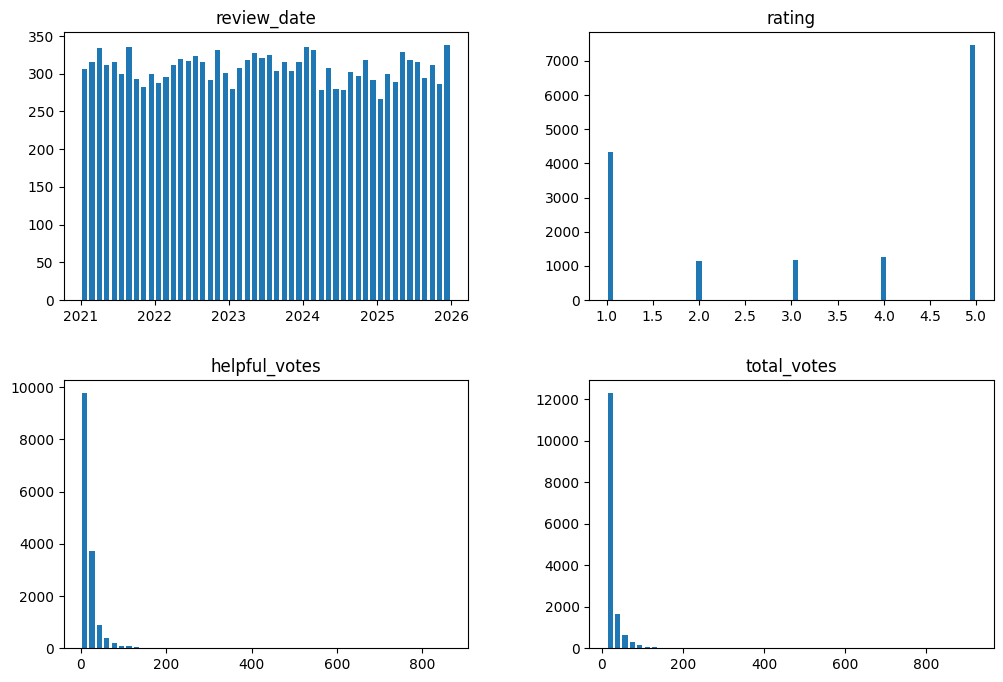

In [184]:
# Distribution of reviews by year
reviews_per_year = reviews_df.groupby(reviews_df['review_date'].dt.year).size()
print(f"The reviews per year:\n{reviews_per_year}")

# Distribution of numeric columns
reviews_df.hist(bins= 50, figsize=(12, 8), grid= False, rwidth = 0.7)

---
## **Task 2: Review Sentiment Classification**

### Sentiment Label Creation

A binary sentiment label was derived from the `rating` column to support the sentiment classification task. Reviews with ratings of **4 or 5** were labelled as *Positive*, while those with ratings of **1 or 2** were labelled as *Negative*.

Reviews with a rating of **3** were treated as neutral or ambiguous and were therefore assigned a `None` value. This decision was made because 3-star reviews often reflect mixed or moderate opinions, which do not clearly belong to either positive or negative categories.

A total of **1,187 reviews** were identified as 3-star ratings and excluded from the training dataset to ensure a clearer binary classification problem.

In [185]:
# Function for sentiment analysis
def sentiment(rating):
    if rating >= 4:
        return "Positive"
    
    if rating <= 2:
        return "Negative"
    
    # Three star rating usually mean the product is okay, not great
    else:
        return None

# Apply function to rating column   
reviews_df["Sentiment"] = reviews_df["rating"].apply(sentiment)

reviews_df.head(5)

# Three star ratings 
print(f"The number of 3 star ratings: {reviews_df["Sentiment"].isna().sum()}")

The number of 3 star ratings: 1187


### Sentiment Distribution

The distribution of sentiment labels shows that **positive reviews significantly outnumber negative reviews**. This indicates a class imbalance in the dataset, with a stronger tendency towards favourable customer feedback.

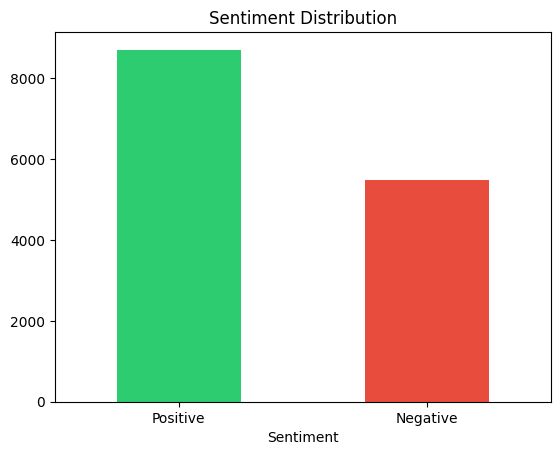

In [186]:
# Plot of distribution
reviews_df["Sentiment"].value_counts().plot(kind= 'bar', color= ['#2ecc71', '#e74c3c'])
plt.xticks(rotation = 0)
plt.title("Sentiment Distribution")
plt.show()

### Converting Sentiment Labels

The sentiment labels were converted into binary values, with *Positive* mapped to **1** and *Negative* mapped to **0**. This allows the data to be used for machine learning models, which require numerical input.

In [187]:
# Convert labels to binary
reviews_df["Sentiment"] = reviews_df["Sentiment"].map({ "Positive": 1, "Negative": 0})

### Text Preprocessing

The `review_body` text was cleaned by converting all characters to lowercase and removing non-alphabetic characters such as punctuation and numbers. This standardisation helps reduce noise in the data and ensures consistency for feature extraction during model training.

In [188]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", "", text)
    return text

reviews_df["review_body"] = reviews_df["review_body"].apply(clean_text)

### Splitting Training and Neutral Data

The dataset was divided into two subsets. The training dataset contains only reviews with clear sentiment labels (*positive* and *negative*), resulting in **14,188 reviews**.

Reviews with missing sentiment labels (i.e., 3-star ratings) were separated into a neutral test set, consisting of **1,187 reviews**. These were excluded from training and used later for additional analysis.

In [189]:
# Training data (only Positive & Negative)
train_df = reviews_df.dropna(subset=["Sentiment"])

# Neutral data (3-star reviews)
test_df = reviews_df[reviews_df["Sentiment"].isna()]

print("Training data has ", train_df.shape[0], " values")
print("Neutral data has ", test_df.shape[0], " values")

Training data has  14188  values
Neutral data has  1187  values


### Feature Extraction and Data Splitting

The review text was converted into numerical features using TF-IDF vectorisation, with a maximum of 5,000 features and removal of common English stop words to reduce noise. The vectoriser was fitted only on the training data to prevent data leakage.

The dataset was then split into training and testing sets using an 80/20 split. This allows the models to be trained on one portion of the data and evaluated on unseen data to assess their performance.


In [190]:
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')

# Fit on training data
X = tfidf.fit_transform(train_df["review_body"])

# Target feature
y = train_df["Sentiment"]

# spilt data
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

### Logistic Regression Model

A Logistic Regression model was trained on the TF-IDF features using the training dataset. The parameter `max_iter=1000` was set to ensure convergence.

Logistic Regression was chosen because it performs well with high-dimensional sparse data such as TF-IDF and is widely used for text classification tasks.

The trained model was then used to predict sentiment labels on the test set.

In [191]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log_model = log_model.predict(X_test)

### Decision Tree Model

A Decision Tree classifier was trained on the TF-IDF features using the training dataset. The parameter `max_depth=10` was used to limit overfitting, and `random_state=42` ensures reproducibility.

Decision Trees were chosen as a non-linear alternative, capable of capturing more complex relationships between features.

The trained model was then used to predict sentiment labels on the test set.

In [192]:
tree_model = DecisionTreeClassifier(max_depth=10, random_state=42)
tree_model.fit(X_train, y_train)

y_pred_tree_model = tree_model.predict(X_test)

### Model Evaluation

The performance of both models was evaluated using accuracy, precision, recall, and F1-score.

Logistic Regression achieved strong results, with an accuracy of **0.874** and an F1-score of **0.900**, indicating a good balance between precision and recall. Its high recall (**0.935**) shows that it is particularly effective at correctly identifying positive reviews.

In comparison, the Decision Tree model achieved a lower accuracy of **0.733** and an F1-score of **0.761**. While its precision (**0.834**) remained relatively high, its lower recall (**0.700**) suggests that it missed a significant number of positive reviews.

Overall, Logistic Regression outperformed the Decision Tree model. This is likely because Logistic Regression is better suited to high-dimensional sparse data such as TF-IDF, whereas Decision Trees tend to struggle and may overfit in such settings.


In [193]:
def evaluate(y_true, y_pred, name):
    print(f"\n{name}")
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall   :", recall_score(y_true, y_pred))
    print("F1 Score :", f1_score(y_true, y_pred))

evaluate(y_test, y_pred_log_model, "Logistic Regression")
evaluate(y_test, y_pred_tree_model, "Decision Tree")


Logistic Regression
Accuracy : 0.8735024665257224
Precision: 0.8674892703862661
Recall   : 0.9352226720647774
F1 Score : 0.9000834956860562

Decision Tree
Accuracy : 0.7325581395348837
Precision: 0.8340220385674931
Recall   : 0.7004048582995951
F1 Score : 0.7613957874882112


### Predicting Sentiment for Neutral Reviews

The trained Logistic Regression model was applied to the 3-star reviews, which were excluded from training due to their ambiguous sentiment. The same TF-IDF vectoriser was used to transform the text to ensure consistency with the training data.

The model classified these neutral reviews as either positive or negative based on their textual content. The results show that **712 reviews were predicted as positive** and **475 as negative**, indicating that even neutral ratings contain underlying sentiment that can be inferred from the review text.

In [194]:
# Transform neutral (3-star) reviews using existing TF-IDF
X_neutral = tfidf.transform(test_df["review_body"])
test_df["Sentiment"] = log_model.predict(X_neutral)

# Counts how many neutral reviews were classified as positive (1) vs negative (0)
test_df["Sentiment"].value_counts()

Sentiment
1.0    712
0.0    475
Name: count, dtype: int64

### Merging Predicted Sentiment

The predicted sentiment labels for the 3-star reviews were merged back into the main dataset using their index to ensure correct alignment.

A check was then performed to confirm that there were no remaining missing values in the `Sentiment` column. This verifies that all previously neutral reviews have been successfully assigned a sentiment label.

This step results in a fully labelled dataset, where all reviews are classified as either positive or negative, enabling further analysis on the complete data.


In [195]:
# Update only the 3-star rows with predictions
reviews_df.loc[test_df.index, "Sentiment"] = test_df["Sentiment"]

# Verify that all missing sentiment values (from 3-star reviews) have been filled after merging predictions
print(f"Number of empty 'Sentiment' rows: {reviews_df["Sentiment"].isnull().sum()}")
reviews_df.head()

Number of empty 'Sentiment' rows: 0


,product_id,user_id,review_title,review_body,review_date,rating,helpful_votes,total_votes,Sentiment
review_id,,,,,,,,,
R274002,B001O1Q0NA,AY6QZ7AY3AK8Z,Fluoridated Salt,i thought this salt was fluoride free unfortun...,2021-01-01,1,17,24,0.0
R302264,B000MOEUMS,A33DXT3AD5DHCB,Not As Advertised,this product is not drinking chocolate i reali...,2021-01-01,3,6,12,1.0
R84546,B002ZOIKMY,A14396UCW3Z0KI,Best Bags For Iced Tea Excellent Deal,first luzianne makes the best classic brewed i...,2021-01-01,5,18,18,1.0
R117515,B0016B7Z32,A1ODU9IV6O87IB,DonT Pay For Expedited Delivery,i paid over for expedited delivery and the pr...,2021-01-01,2,4,22,0.0
R131840,B001XUO8AY,A3LOCNXB7Z1WCH,I Love FeverTree,after doing an internet search for tonic water...,2021-01-01,5,16,16,1.0


---
## **Task 3: Review Helpfulness Classification**

### Creating Helpfulness Labels

A binary helpfulness label was created directly from the `helpful_votes` and `total_votes` columns using a row-wise function. For each review, the proportion of helpful votes was calculated by dividing the number of helpful votes by the total votes.

$$
\text{helpfulness ratio} = \frac{\text{helpful votes}}{\text{total votes}}
$$

A threshold of 0.5 was used, meaning a review is classified as helpful if at least half of the users who voted found it helpful. Reviews with a lower proportion were classified as unhelpful.

To handle edge cases, reviews with zero total votes were automatically classified as unhelpful to avoid division errors.

The distribution of helpfulness labels shows a clear imbalance in the dataset. The majority of reviews are classified as helpful (1), while a smaller proportion are labelled as unhelpful (0).

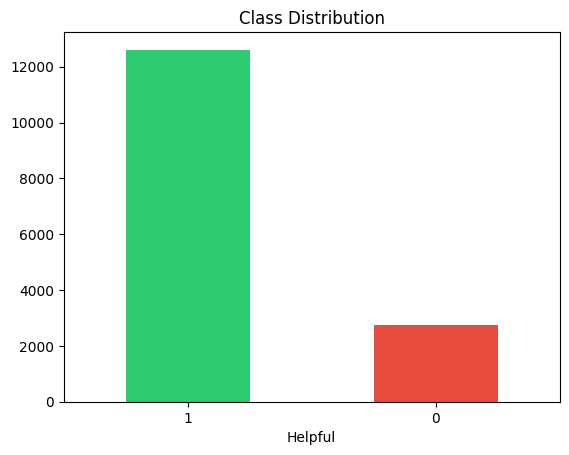

In [196]:
# Create binary helpfulness label: 1 if ≥50% votes are helpful, else 0 (handles zero votes safely)
reviews_df["Helpful"] = reviews_df.apply(
    lambda row: 1 if row["total_votes"] > 0 and (row["helpful_votes"] / row["total_votes"]) >= 0.5 else 0,
    axis=1
)

# Plot of distribution
reviews_df["Helpful"].value_counts().plot(kind= 'bar', color= ['#2ecc71', '#e74c3c'])
plt.xticks(rotation = 0)
plt.title("Class Distribution")
plt.show()

### Feature Preparation and Data Splitting

The review text was transformed into numerical features using the previously fitted TF-IDF vectoriser. These features represent the input data for the helpfulness classification task, while the `Helpful` column serves as the target variable.

The dataset was then split into training and testing sets using an 80/20 split. This allows the models to be trained on one portion of the data and evaluated on unseen data to assess their generalisation performance.

In [197]:
# TF-IDF features (already fitted earlier)
X_text = tfidf.transform(reviews_df["review_body"])

# Target
y_helpful = reviews_df["Helpful"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_text, y_helpful, test_size=0.2, random_state=42 )


### Logistic Regression Model 

The Logistic Regression model was trained on the TF-IDF features using the training dataset. The same model configuration was reused to maintain consistency with the sentiment classification task.

The trained model was then used to predict whether reviews are helpful or unhelpful on the test set.


In [198]:
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

### Decision Tree Model 

The Decision Tree model was trained on the TF-IDF features using the training dataset. The same configuration was used as in the sentiment classification task to ensure consistency.

The trained model was then used to predict whether reviews are helpful or unhelpful on the test set.


In [199]:
tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

### Model Evaluation

Both models performed well on the helpfulness classification task, achieving relatively high scores across all evaluation metrics.

Logistic Regression achieved an accuracy of **0.848** and an F1-score of **0.914**, slightly outperforming the Decision Tree model. It also maintained a high precision (**0.849**) and very high recall (**0.990**), indicating that it correctly identified most helpful reviews.

The Decision Tree model achieved an accuracy of **0.826** and an F1-score of **0.903**. While its recall (**0.990**) was equal to Logistic Regression, its lower precision (**0.829**) suggests it produced more false positives when predicting helpful reviews.

Overall, Logistic Regression performed better than the Decision Tree model, although the difference in performance is smaller compared to the sentiment classification task. This suggests that helpfulness may be easier to predict or less sensitive to model choice than sentiment.

In [200]:
evaluate(y_test, y_pred_log, "Logistic Regression")
evaluate(y_test, y_pred_tree, "Decision Tree")


Logistic Regression
Accuracy : 0.848130081300813
Precision: 0.8485263879369431
Recall   : 0.9900039984006398
F1 Score : 0.9138217383281049

Decision Tree
Accuracy : 0.8263414634146341
Precision: 0.8294807370184255
Recall   : 0.9900039984006398
F1 Score : 0.9026613197229311


### Comparison Between Sentiment and Helpfulness Classification

The sentiment and helpfulness classification tasks show clear differences in model performance.

For sentiment classification, Logistic Regression achieved higher accuracy (**0.874**) compared to helpfulness classification (**0.848**), indicating that sentiment is generally easier to predict. This is because sentiment is directly expressed in the review text through clear positive or negative language, making it more accessible to text-based models.

In contrast, helpfulness classification achieved very high recall (**0.99**) for both models, but slightly lower precision. This suggests that the models tend to classify most reviews as helpful, likely due to class imbalance where helpful reviews dominate the dataset. As a result, the models prioritise identifying helpful reviews, leading to more false positives.

Another key difference is the performance gap between models. In the sentiment task, Logistic Regression significantly outperformed the Decision Tree (F1: **0.900 vs 0.761**), demonstrating that linear models are better suited to high-dimensional text data. However, in the helpfulness task, the performance gap is much smaller (F1: **0.914 vs 0.903**), suggesting that helpfulness is less dependent on model choice and harder to capture using text features alone.

Additionally, the sentiment classification task excluded neutral (3-star) reviews, resulting in a cleaner and more clearly defined binary problem. This likely contributed to its stronger and more stable performance compared to the more subjective and noisy helpfulness classification task.

Overall, sentiment classification is more straightforward and yields better performance, while helpfulness classification is more complex due to its subjective nature, class imbalance, and weaker relationship with textual features.
